In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu, wilcoxon
import matplotlib.pyplot as plt


traditional_immediate = np.array([0.60, 0.75, 0.65, 0.40, 0.65, 0.70])
socratic_immediate   = np.array([0.50, 0.35, 0.60, 0.45, 0.55, 0.50])

traditional_retention = np.array([0.40, 0.45, 0.50, 0.25, 0.40, 0.75])
socratic_retention   = np.array([0.60, 0.25, 0.60, 0.30, 0.60, 0.70])

# =========================
# CLIFF'S DELTA
# =========================

def cliffs_delta(x, y):
    n_x = len(x)
    n_y = len(y)

    greater = 0
    lower = 0

    for xi in x:
        for yi in y:
            if xi > yi:
                greater += 1
            elif xi < yi:
                lower += 1

    return (greater - lower) / (n_x * n_y)

# =========================
# DESCRIPTIVE STATS
# =========================

def describe(name, immediate, retention):
    print(f"\n{name}")
    print("-" * 40)
    print(f"Immediate scores: {immediate}")
    print(f"Retention scores: {retention}")

    mean_immediate = np.mean(immediate)
    sd_immediate = np.std(immediate, ddof=1)

    mean_retention = np.mean(retention)
    sd_retention = np.std(retention, ddof=1)

    delta = mean_retention - mean_immediate

    print(f"Immediate Mean: {mean_immediate:.3f}")
    print(f"Immediate SD:   {sd_immediate:.3f}")
    print(f"Retention Mean: {mean_retention:.3f}")
    print(f"Retention SD:   {sd_retention:.3f}")
    print(f"Change (Δ):     {delta:.3f}")

describe("Traditional", traditional_immediate, traditional_retention)
describe("Socratic", socratic_immediate, socratic_retention)

# =========================
# BETWEEN-GROUP TESTS
# =========================

print("\n" + "="*50)
print("BETWEEN-GROUP COMPARISONS")
print("="*50)

u_immediate, p_immediate = mannwhitneyu(
    traditional_immediate,
    socratic_immediate,
    alternative='two-sided'
)

delta_immediate = cliffs_delta(traditional_immediate, socratic_immediate)

print("\nImmediate Post-Test")
print(f"Mann-Whitney U: {u_immediate}")
print(f"p-value:        {p_immediate:.4f}")
print(f"Cliff's delta:  {delta_immediate:.3f}")

u_retention, p_retention = mannwhitneyu(
    traditional_retention,
    socratic_retention,
    alternative='two-sided'
)

delta_retention = cliffs_delta(traditional_retention, socratic_retention)

print("\nRetention Test")
print(f"Mann-Whitney U: {u_retention}")
print(f"p-value:        {p_retention:.4f}")
print(f"Cliff's delta:  {delta_retention:.3f}")

# =========================
# WITHIN-GROUP TESTS
# =========================

print("\n" + "="*50)
print("WITHIN-GROUP COMPARISONS")
print("="*50)

w_trad, p_trad = wilcoxon(
    traditional_immediate,
    traditional_retention,
    alternative='two-sided'
)

print("\nTraditional: Immediate vs Retention")
print(f"Wilcoxon W: {w_trad}")
print(f"p-value:    {p_trad:.4f}")

w_soc, p_soc = wilcoxon(
    socratic_immediate,
    socratic_retention,
    alternative='two-sided'
)

print("\nSocratic: Immediate vs Retention")
print(f"Wilcoxon W: {w_soc}")
print(f"p-value:    {p_soc:.4f}")


Traditional
----------------------------------------
Immediate scores: [0.6  0.75 0.65 0.4  0.65 0.7 ]
Retention scores: [0.4  0.45 0.5  0.25 0.4  0.75]
Immediate Mean: 0.625
Immediate SD:   0.121
Retention Mean: 0.458
Retention SD:   0.166
Change (Δ):     -0.167

Socratic
----------------------------------------
Immediate scores: [0.5  0.35 0.6  0.45 0.55 0.5 ]
Retention scores: [0.6  0.25 0.6  0.3  0.6  0.7 ]
Immediate Mean: 0.492
Immediate SD:   0.086
Retention Mean: 0.508
Retention SD:   0.186
Change (Δ):     0.017

BETWEEN-GROUP COMPARISONS

Immediate Post-Test
Mann-Whitney U: 30.5
p-value:        0.0534
Cliff's delta:  0.694

Retention Test
Mann-Whitney U: 14.5
p-value:        0.6273
Cliff's delta:  -0.194

WITHIN-GROUP COMPARISONS

Traditional: Immediate vs Retention
Wilcoxon W: 1.0
p-value:    0.0625

Socratic: Immediate vs Retention
Wilcoxon W: 6.5
p-value:    0.7865


/Users/marcelomachado/Documents/projects/socratic-ai/.venv/lib/python3.9/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


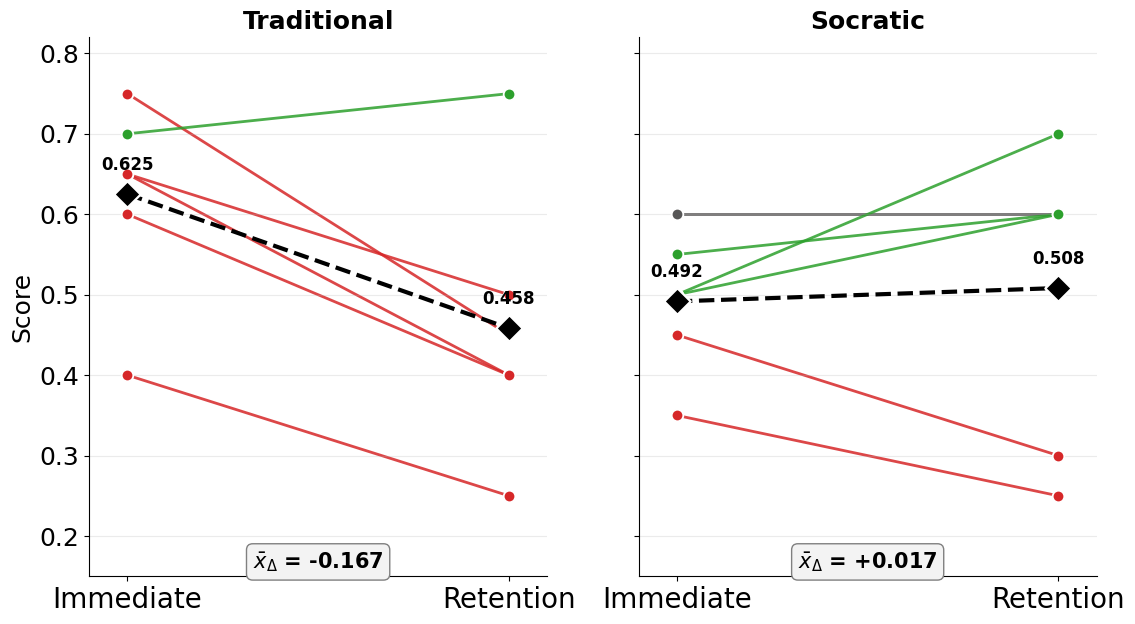

In [38]:
groups = [
    ("Traditional",
     traditional_immediate,
     traditional_retention),

    ("Socratic",
     socratic_immediate,
     socratic_retention)
]


plt.rcParams.update({
    "font.size":12,
    "axes.spines.top":False,
    "axes.spines.right":False,
})


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13,7),
    sharey=True
)

for ax, (title, immediate, retention) in zip(axes, groups):

    mean_im = immediate.mean()
    mean_ret = retention.mean()
    delta = mean_ret - mean_im

    for i in range(len(immediate)):

        if retention[i] > immediate[i]:
            color = "#2ca02c" 
        elif retention[i] < immediate[i]:
            color = "#d62728"
        else:
            color = "#575656"

        ax.plot(
            [0,1],
            [immediate[i], retention[i]],
            color=color,
            lw=2,
            alpha=.85,
            zorder=1
        )

        ax.scatter(
            [0,1],
            [immediate[i], retention[i]],
            color=color,
            s=70,
            edgecolor="white",
            linewidth=1.3,
            zorder=2
        )

    ax.plot(
        [0,1],
        [mean_im, mean_ret],
        color="black",
        lw=3,
        ls="--",
        zorder=3
    )

    ax.scatter(
        [0,1],
        [mean_im, mean_ret],
        marker="D",
        s=180,
        color="black",
        edgecolor="white",
        linewidth=1.6,
        zorder=4
    )

    ax.text(
        0,
        mean_im+0.03,
        f"{mean_im:.3f}",
        ha="center",
        fontweight="bold"
    )

    ax.text(
        1,
        mean_ret+0.03,
        f"{mean_ret:.3f}",
        ha="center",
        fontweight="bold"
    )

    ax.text(.5, 0.16, rf"$\bar{{x}}_{{\Delta}}$ = {delta:+.3f}", ha="center", fontsize=15, fontweight="bold",
            bbox=dict(facecolor="#f3f3f3", edgecolor="gray", boxstyle="round,pad=.3"))

    ax.set_title(title, fontsize=18, weight="bold")
    ax.set_xticks([0,1])
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xticklabels(["Immediate","Retention"], fontsize=20)
    ax.grid(axis="y", alpha=.25)
    ax.margins(x=0.1)

axes[0].set_ylabel("Score", fontsize=18)


plt.ylim(0.15,0.82)

plt.savefig("individual_changes.pdf", dpi=300, bbox_inches="tight")
plt.show()